# Density approximation of $V_Y$: SVCJ

Neither Pearson nor Laguerre cannot approxiamte the density of $V_t$ !!!

In [20]:
from pearsondist import Pearson8, Support8

from utils import plot_pdf_cdf, plot_dpdf_pdf
from joint_mom import comp_joint_moms_mat
from joint_mom_tr import joint_mom_tr, joint_mom_tr_row, index
import numpy as np

In [21]:
jointMomRow = np.loadtxt('svcj_mu_vy_row.txt', delimiter=' ', dtype=float).tolist()

In [22]:
degree = 4
mu_d1 = [joint_mom_tr_row(i, 0, jointMomRow) for i in range(1, 2*degree + 1)]
mu_x2 = [jointMomRow[index(0, i)] for i in range(1, 2*degree + 1)]
mu_d2 = [joint_mom_tr_row(0, i, jointMomRow) for i in range(1, 2*degree + 1)]
mu_d1d2 = [[joint_mom_tr_row(i, j, jointMomRow) for j in range(degree + 1)] for i in range(degree + 1)]

## Pearson Density Approximation ($\zeta_1 = x_1$): $V_t$

{'A1': np.float64(1.927246738492311),
 'A2': np.float64(0.7283037603826658),
 'A3': np.float64(-2.6555504988749767),
 'B3': np.float64(2.933620594562306),
 'type': 44,
 'x1': np.float64(-0.04906480342832593),
 'x2': np.float64(0.005601278708472017),
 'x3': np.complex128(0.5353202745967597+0.29300446341060304j)}
a = 0.00777757401582114, scale = 13.555505509866165
is_max: False
pdf(-a) = 1.0000000


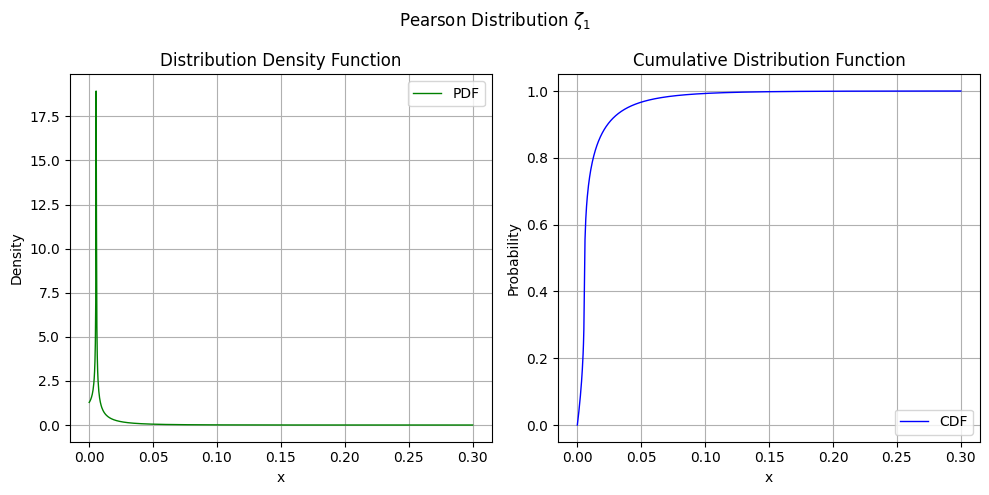

pdf(0.0001000) = 1.28e+00, pdf(0.3000000) = 5.87e-05


In [29]:
from pprint import pprint

pearson = Pearson8(mu_d1)
pprint(pearson.pfd) # print(pearson.mom)
print(f'a = {pearson.coef[0]}, scale = {pearson.pdf_obj.scale}') # print("coef: ", pearson.coef)
print(f'is_max: {pearson.pdf_obj.is_max}')
print(f'pdf(-a) = {pearson.pdf(-pearson.coef[0]):.7f}')
# lbub = pearson.determine_bounds()

lbub = (0.00561, 0.536480111)
lbub = (0.0001, 0.3)
x = np.linspace(lbub[0], lbub[1], 1000)

pdf = pearson.pdf(x); title = r'Pearson Distribution $\zeta_1$'
plot_pdf_cdf(x, pdf, title)
dpdf = pearson.dpdf(x); title = 'PDF and its Derivative'
# support8 = Support8(pearson.pdf_obj)
# bounds = support8.determine_bounds()
# print(f'bounds: ({bounds[0]:.5f},{bounds[1]:.5f})')

# roots = support8.pdf_obj.ddpdf_roots()
# plot_dpdf_pdf(x, dpdf, pdf, title, roots)

print(f'pdf({lbub[0]:.7f}) = {pearson.pdf(lbub[0]):.2e}, pdf({lbub[1]:.7f}) = {pearson.pdf(lbub[1]):.2e}')

## Pearson Density Approximation ($x_2$): $Y_t$

{'A1': np.float64(-3.9228850282968812),
 'A2': np.float64(3.9228850282968812),
 'B1': np.float64(-16.183559201266746),
 'B2': np.float64(-0.22556999223079213),
 'type': 42,
 'x1': np.complex128(-1.846918935371237+1.2208023133400887j),
 'x2': np.complex128(0.2445429702331643+0.13716791817353016j)}
a = -0.09145328370712558, scale = 21.33799584710358
iteration: 0, x0 =   -0.0819129
iteration: 1, x0 =   -0.2100228
iteration: 2, x0 =   -0.3299464
iteration: 3, x0 =   -0.4506637
iteration: 4, x0 =   -0.5732009
iteration: 5, x0 =   -0.6970326
iteration: 6, x0 =   -0.8212399
iteration: 7, x0 =   -0.9449457
iteration: 0, x0 =    0.2613301
iteration: 1, x0 =    0.2869900
iteration: 2, x0 =    0.3114984
iteration: 3, x0 =    0.3365378
iteration: 4, x0 =    0.3633249
iteration: 5, x0 =    0.3930191
iteration: 6, x0 =    0.4269306
iteration: 7, x0 =    0.4666988
iteration: 8, x0 =    0.5145098
iteration: 9, x0 =    0.5734182
iteration: 10, x0 =    0.6478733


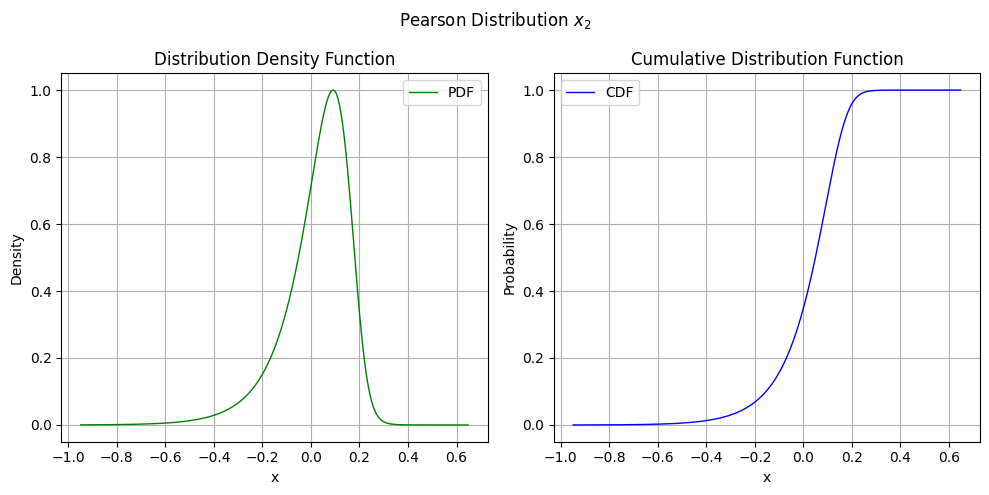

iteration: 0, x0 =   -0.0819129
iteration: 1, x0 =   -0.2100228
iteration: 2, x0 =   -0.3299464
iteration: 3, x0 =   -0.4506637
iteration: 4, x0 =   -0.5732009
iteration: 5, x0 =   -0.6970326
iteration: 6, x0 =   -0.8212399
iteration: 7, x0 =   -0.9449457
iteration: 0, x0 =    0.2613301
iteration: 1, x0 =    0.2869900
iteration: 2, x0 =    0.3114984
iteration: 3, x0 =    0.3365378
iteration: 4, x0 =    0.3633249
iteration: 5, x0 =    0.3930191
iteration: 6, x0 =    0.4269306
iteration: 7, x0 =    0.4666988
iteration: 8, x0 =    0.5145098
iteration: 9, x0 =    0.5734182
iteration: 10, x0 =    0.6478733


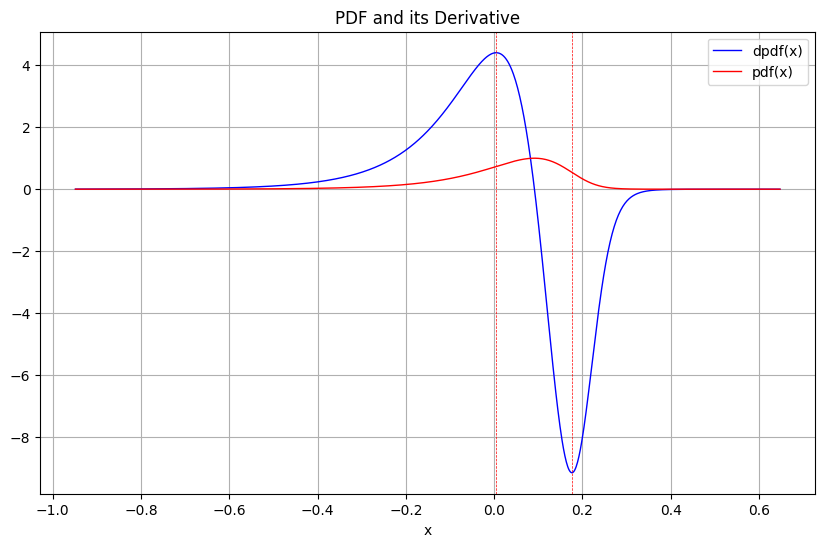

pdf(-0.9487437) = 3.38e-04, pdf(0.6478733) = 3.87e-06


In [24]:
from pearsondist.pearson8 import Pearson8

pearson = Pearson8(mu_x2)

pprint(pearson.pfd) # print(pearson.mom)
print(f'a = {pearson.coef[0]}, scale = {pearson.pdf_obj.scale}') # print("coef: ", pearson.coef)
lbub = pearson.determine_bounds()

# lbub = (-1.8, 1.0)
x = np.linspace(lbub[0], lbub[1], 1000)

# txt = ','.join(f'{mu_:.9f}' for mu_ in mu_x2); print(f'mu_x2 = [{txt}]')

pdf = pearson.pdf(x); title = r'Pearson Distribution $x_2$'
plot_pdf_cdf(x, pdf, title)

dpdf = pearson.dpdf(x); title = 'PDF and its Derivative'
support8 = Support8(pearson.pdf_obj); roots = support8.pdf_obj.ddpdf_roots()
plot_dpdf_pdf(x, dpdf, pdf, title, roots)

print(f'pdf({lbub[0]:.7f}) = {pearson.pdf(lbub[0]):.2e}, pdf({lbub[1]:.7f}) = {pearson.pdf(lbub[1]):.2e}')

## Pearson Density Approximation ($\zeta_2$): $Y_t + c V_t$

The transformed variable $\zeta_2 = Y_t + c V_t$,

$c = -\frac{\mathrm{cov}(I_t, dI\!E_t)}{\mathrm{var}(I_t)} = -0.2825008$

$\mathrm{cov}(\zeta_1, \zeta_2) = \mathrm{cov}(I_t, dI\!E_t + c I_t) = \mathrm{cov}(I_t, dI\!E_t) + c \times\mathrm{var}(I_t) = 0$

{'A1': np.float64(-2.877648365852382),
 'A2': np.float64(-2.1099522269336615),
 'A3': np.float64(4.987600592786044),
 'B3': np.float64(-0.4752823185792205),
 'type': 44,
 'x1': np.float64(-1.3762739371774209),
 'x2': np.float64(2.4154789482959464),
 'x3': np.complex128(0.161540106147883+0.1756749733875617j)}
a = -0.10241482762262076, scale = 11.912013373223115
iteration: 0, x0 =   -0.0478941
iteration: 1, x0 =   -0.1399159
iteration: 2, x0 =   -0.2296956
iteration: 3, x0 =   -0.3247083
iteration: 4, x0 =   -0.4267134
iteration: 5, x0 =   -0.5354576
iteration: 6, x0 =   -0.6491415
iteration: 7, x0 =   -0.7645451
iteration: 0, x0 =    0.2517025
iteration: 1, x0 =    0.3037453
iteration: 2, x0 =    0.3546655
iteration: 3, x0 =    0.4091876
iteration: 4, x0 =    0.4700818
iteration: 5, x0 =    0.5397454
iteration: 6, x0 =    0.6205849
iteration: 7, x0 =    0.7151089
iteration: 8, x0 =    0.8258504
iteration: 9, x0 =    0.9550902
lbub: [np.float64(-0.799438910855426), np.float64(0.998140909

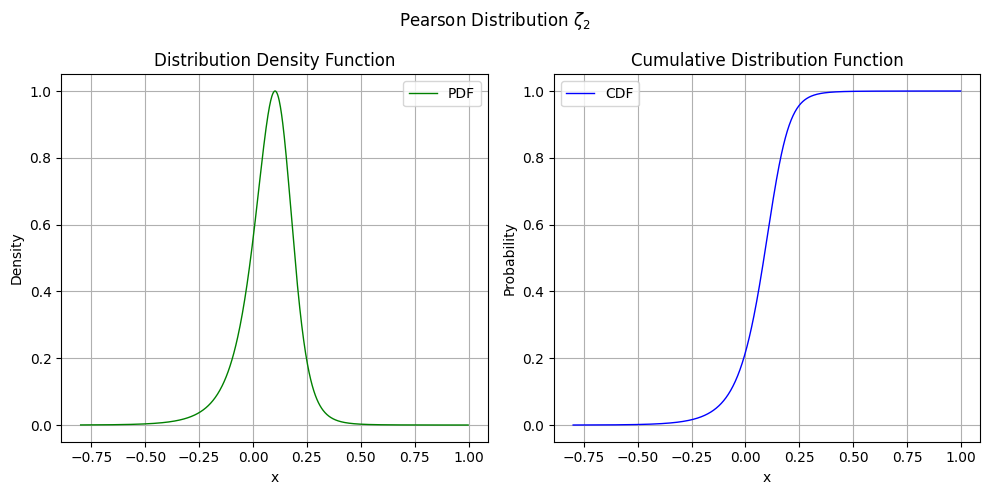

iteration: 0, x0 =   -0.0478941
iteration: 1, x0 =   -0.1399159
iteration: 2, x0 =   -0.2296956
iteration: 3, x0 =   -0.3247083
iteration: 4, x0 =   -0.4267134
iteration: 5, x0 =   -0.5354576
iteration: 6, x0 =   -0.6491415
iteration: 7, x0 =   -0.7645451
iteration: 0, x0 =    0.2517025
iteration: 1, x0 =    0.3037453
iteration: 2, x0 =    0.3546655
iteration: 3, x0 =    0.4091876
iteration: 4, x0 =    0.4700818
iteration: 5, x0 =    0.5397454
iteration: 6, x0 =    0.6205849
iteration: 7, x0 =    0.7151089
iteration: 8, x0 =    0.8258504
iteration: 9, x0 =    0.9550902


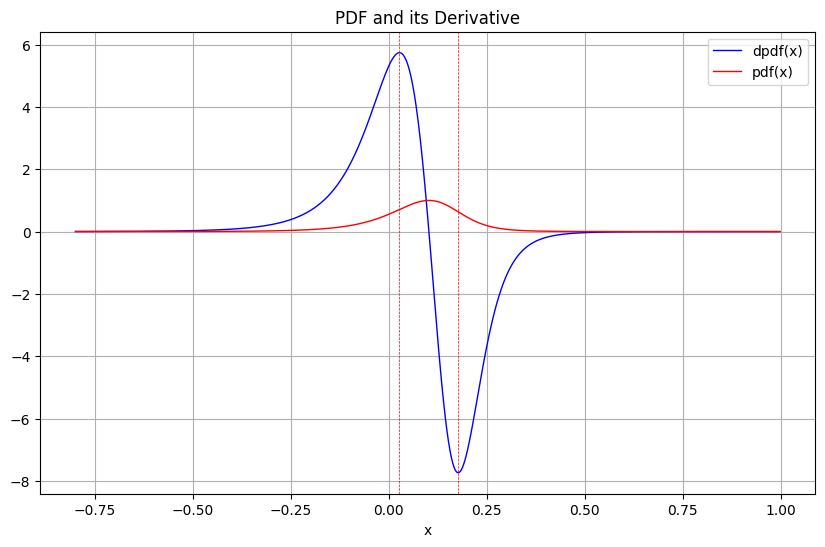

pdf(-0.7994389) = 2.48e-04, pdf(0.9981409) = 2.84e-05


In [25]:
pearson = Pearson8(mu_d2)
pprint(pearson.pfd)
print(f'a = {pearson.coef[0]}, scale = {pearson.pdf_obj.scale}') # print("coef: ", pearson.coef)
lbub = pearson.determine_bounds()

# lbub = (-1.376264, 1.122211)
print(f'lbub: {lbub}')
x = np.linspace(lbub[0], lbub[1], 1000)

pdf = pearson.pdf(x); title = r'Pearson Distribution $\zeta_2$'
plot_pdf_cdf(x, pdf, title)

dpdf = pearson.dpdf(x); title = 'PDF and its Derivative'
support8 = Support8(pearson.pdf_obj); roots = support8.pdf_obj.ddpdf_roots()
plot_dpdf_pdf(x, dpdf, pdf, title, roots)

print(f'pdf({lbub[0]:.7f}) = {pearson.pdf(lbub[0]):.2e}, pdf({lbub[1]:.7f}) = {pearson.pdf(lbub[1]):.2e}')